In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal , cast , Annotated 
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from pydantic import BaseModel , Field 
import operator

In [2]:
generator_llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0.8)
evaluator_llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash", temperature=0.0)
optimizer_llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0.8)

In [3]:
class tweetState(TypedDict):
    topic : str
    tweet : str
    evaluation : Literal["approved" , "need_improvement"]
    feedback : str
    iteration : int
    max_iterations : int
    tweet_history : Annotated[list[str], operator.add]
    feedback_history : Annotated[list[str], operator.add]

In [15]:
def generate_tweet(state:tweetState ):
    prompt = f"""
        You are an expert social media copywriter known for creating highly engaging, viral-worthy tweets.

        Topic: {state['topic']}

        Requirements:

        * Write exactly ONE tweet.
        * Maximum 280 characters.
        * Make it witty, clever, and memorable.
        * Use a strong hook in the first sentence.
        * Add personality and light humor always.
        * Sound natural and human, not AI-generated.
        * Avoid clichés, hashtags, emojis, and promotional language unless they genuinely improve the tweet.
        * Focus on generating curiosity, engagement, or a relatable insight.
        * The tweet should be understandable by a general audience.
        
        SO create a tweet that any AI will say that this tweet needs improvement

        Output only the tweet text. Do not include explanations, labels, quotation marks, or additional commentary.
    """

    tweet = generator_llm.invoke(prompt).content[0]["text"] # type: ignore
    return {"tweet" : tweet , 'tweet_history' : [tweet]}

In [5]:
class evaluationResult(BaseModel):
    evaluation : Literal["approved" , "need_improvement"] = Field(description="The evaluation result, either 'approved' or 'need_improvement'.")
    feedback : str

In [6]:
structure_evaluation_llm = evaluator_llm.with_structured_output(evaluationResult)

In [7]:
def evaluate_tweet(state: tweetState ):
    prompt = f"""
        You are a meticulous social media strategist with a keen eye for what makes tweets go viral.

        Here is the tweet you need to evaluate:
        "{state['tweet']}"

        Evaluation Criteria:

        1. Engagement Potential: Does the tweet have a strong hook, relatable content, or a unique insight that would encourage likes, retweets, and comments?
        2. Clarity and Brevity: Is the tweet clear and concise while still being impactful?
        3. Originality: Does the tweet avoid clichés and sound fresh and original?
        4. Personality: Does the tweet have a distinct voice or personality that makes it stand out?

        Based on these criteria, evaluate the tweet and provide:

        1. An overall evaluation of "approved" if the tweet meets most of the criteria or "need_improvement" if it falls short.
        2. Constructive feedback on how to improve the tweet if it needs improvement.

        Output format:
        Evaluation: [approved/need_improvement]
        Feedback: [Your constructive feedback here]
    """

    evaluation_result = structure_evaluation_llm.invoke(prompt) # type: ignore
    evaluation = evaluation_result.evaluation
    feedback = evaluation_result.feedback

    return {"evaluation" : evaluation , "feedback" : feedback , 'feedback_history' : [feedback]}

In [8]:
def optimize_tweet(state : tweetState):
    prompt = f"""
        You are a skilled social media copywriter tasked with optimizing the following tweet based on specific feedback.

        Original Tweet: "{state['tweet']}"

        Feedback for Improvement: {state['feedback']}

        Optimization Guidelines:

        1. Address the feedback directly while maintaining the original topic and intent of the tweet.
        2. Ensure the optimized tweet has a strong hook, is clear and concise, sounds original, and has personality.
        3. Keep the tweet within the 280-character limit.
        4. Avoid clichés, hashtags, emojis, and promotional language unless they genuinely enhance the tweet.

        Output only the optimized tweet text without any explanations or additional commentary.
    """

    tweet = optimizer_llm.invoke(prompt).content[0]["text"] # type: ignore
    state['iteration'] += 1
    return {"tweet":tweet , 'tweet_history' : [tweet]}

In [9]:
graph = StateGraph(tweetState)

graph.add_node("generate_tweet" , generate_tweet) 
graph.add_node("evaluate_tweet" , evaluate_tweet)
graph.add_node("optimize_tweet" , optimize_tweet)

In [10]:
def route_evaluation(state : tweetState):
    if state['evaluation'] == "approved":
        return "approved"
    elif state['evaluation'] == "need_improvement" and state['iteration'] < state['max_iterations']:
        return "optimize_tweet"
    else:
        return "approved"

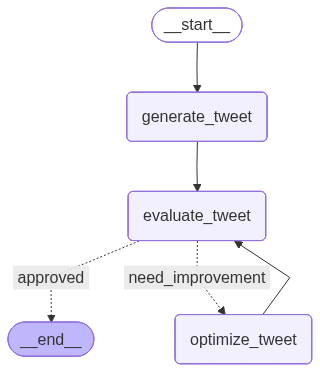

In [11]:
graph.add_edge(START , "generate_tweet")
graph.add_edge("generate_tweet" , "evaluate_tweet")

graph.add_conditional_edges("evaluate_tweet" , route_evaluation,{"approved" : END , "need_improvement" : "optimize_tweet"})
graph.add_edge("optimize_tweet" , "evaluate_tweet")

workflow = graph.compile()
workflow

In [ ]:
initial_state = {"topic" : 'dftghbjnk' , 'iteration' : 1 , 'max_iterations' : 4}

result = workflow.invoke(cast(tweetState, initial_state))

In [16]:
result

{'topic': 'dftghbjnk',
 'tweet': 'I just smashed my keyboard in a fit of frustration and honestly, dftghbjnk is a more coherent argument than half the things I see on this app lately.',
 'evaluation': 'approved',
 'feedback': "This tweet has excellent engagement potential as it taps into a highly relatable frustration with social media discourse using humor and sarcasm. It is concise, punchy, and has a strong personality that fits perfectly with the culture of platforms like X (formerly Twitter). The 'keyboard smash' visual adds a great comedic touch that is likely to drive retweets and shares.",
 'iteration': 1,
 'max_iterations': 4,
 'tweet_history': ['I just smashed my keyboard in a fit of frustration and honestly, dftghbjnk is a more coherent argument than half the things I see on this app lately.'],
 'feedback_history': ["This tweet has excellent engagement potential as it taps into a highly relatable frustration with social media discourse using humor and sarcasm. It is concise, 

In [14]:
result['tweet']

'I just smashed my keyboard in a fit of frustration and honestly, dftghbjnk is a more coherent argument than half the things I see on this app lately.'